# Task 4 — Spam SMS Detection

**CodSoft ML Internship**

Given the text of an SMS message, decide whether it is **spam** or **ham** (legitimate).

- **Dataset:** [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) — 5,572 real SMS messages, hand-labelled. Originally collected by Almeida & Gómez Hidalgo (UCI ML Repository).
- **Approach:** TF-IDF features → linear classifier, wrapped in a scikit-learn `Pipeline`.
- **Headline metric:** F1 on the *spam* class. Not accuracy — this dataset is ~13% spam, so a model that predicts "ham" for everything scores 87% accuracy while catching zero spam.

This notebook is a walkthrough: every step says what it does and why.

In [1]:
import re
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42            # fixed everywhere, so every run reproduces
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

HAM, SPAM = "ham", "spam"

---
## 1. Load the data

The file is **`latin-1` encoded**, not UTF-8 — reading it as UTF-8 raises a `UnicodeDecodeError`.
It also has five columns where you would expect two.

In [2]:
raw = pd.read_csv("data/spam.csv", encoding="latin-1")
print("shape:", raw.shape)
print("columns:", list(raw.columns))
raw.head()

shape: (5572, 5)
columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Ci...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 t...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


### 1.1 What are those three unnamed columns?

The usual advice is "drop the three junk columns". Before dropping anything, let's look at what is
actually in them — 50 rows are non-empty, and dropping them would silently truncate real messages.

In [3]:
junk_cols = [c for c in raw.columns if c.startswith("Unnamed")]
overflow = raw[raw[junk_cols].notna().any(axis=1)]
print(f"rows with content in the unnamed columns: {len(overflow)}\n")

for _, row in overflow.head(2).iterrows():
    print(f"label : {row['v1']}")
    print(f"v2    : {row['v2']!r}")
    for c in junk_cols:
        if pd.notna(row[c]):
            print(f"{c:12s}: {row[c]!r}")
    print("-" * 100)

rows with content in the unnamed columns: 50

label : spam
v2    : 'Your free ringtone is waiting to be collected. Simply text the password \\MIX\\" to 85069 to verify. Get Usher and Britney. FML'
Unnamed: 2  : ' PO Box 5249'
Unnamed: 3  : ' MK17 92H. 450Ppw 16"'
----------------------------------------------------------------------------------------------------
label : ham
v2    : '\\Wen u miss someone'
Unnamed: 2  : ' the person is definitely special for u..... But if the person is so special'
Unnamed: 3  : ' why to miss them'
Unnamed: 4  : ' just Keep-in-touch\\" gdeve.."'
----------------------------------------------------------------------------------------------------


That is not junk — it is **one message that got split across columns**.

The original corpus is a plain text file. When it was converted to CSV, messages containing a comma
inside a broken quote were split at the comma, so the tail of the message spilled into
`Unnamed: 2`, `3`, `4`. Dropping those columns would silently truncate 50 messages
(and they are disproportionately spam, which is exactly the class we care about).

So instead of dropping, we **re-join** the pieces with the comma that split them.

In [4]:
def repair_message(row):
    '''Re-join a message that the CSV converter split across the overflow columns.'''
    parts = [str(row["v2"])] + [str(row[c]) for c in junk_cols if pd.notna(row[c])]
    return ",".join(parts)

df = pd.DataFrame({
    "label": raw["v1"],
    "message": raw.apply(repair_message, axis=1),
})

repaired = (df["message"].str.len() > raw["v2"].str.len()).sum()
print(f"messages repaired: {repaired}")
print(f"spam among repaired: {(df.loc[df['message'].str.len() > raw['v2'].str.len(), 'label'] == SPAM).sum()}")
df.head(3)

messages repaired: 50
spam among repaired: 5


,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Ci..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 t...


### 1.2 Duplicates — and why they matter more than they look

There are exact duplicate messages in this corpus (the same SMS was collected more than once).
If a duplicate lands in the training set *and* the test set, the model has memorised the answer and
the test score is inflated. That is **leakage**, and it is the most common silent bug in a text
classification project.

We count them, measure the leak, then drop them — and report exactly what was dropped.

In [5]:
n_before = len(df)
dupes = df.duplicated(subset=["message"]).sum()
conflicting = (df.groupby("message")["label"].nunique() > 1).sum()
print(f"exact duplicate messages : {dupes}")
print(f"duplicates with conflicting labels : {conflicting}   (0 means the labels are at least consistent)")
print("\nduplicates by class:")
print(df[df.duplicated(subset=['message'])]["label"].value_counts().to_string())

# How many duplicated messages would end up on both sides of a naive split?
_Xtr, _Xte = train_test_split(df["message"], test_size=0.2,
                              stratify=df["label"], random_state=RANDOM_STATE)
print(f"\nmessages appearing in BOTH train and test if we do not dedupe: {len(set(_Xte) & set(_Xtr))}")

df = df.drop_duplicates(subset=["message"]).reset_index(drop=True)
print(f"\ndropped {n_before - len(df)} duplicate rows -> {len(df)} unique messages remain")

exact duplicate messages : 403
duplicates with conflicting labels : 0   (0 means the labels are at least consistent)

duplicates by class:
label
ham     309
spam     94



messages appearing in BOTH train and test if we do not dedupe: 115

dropped 403 duplicate rows -> 5169 unique messages remain


---
## 2. Exploratory data analysis

### 2.1 Class balance

This is the single most important plot in the notebook, because it decides which metric we are
allowed to trust.

label
ham     4516
spam     653

spam rate: 12.63%
accuracy of a 'predict ham for everything' baseline: 87.37%


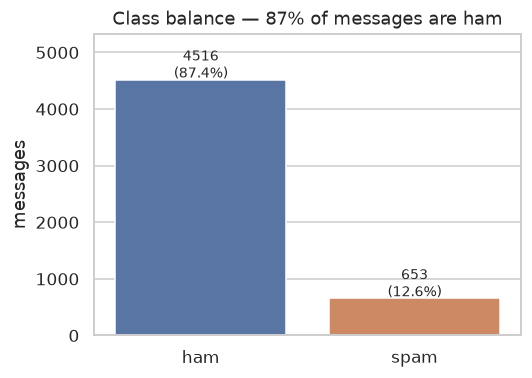

In [6]:
counts = df["label"].value_counts()
spam_rate = (df["label"] == SPAM).mean()
print(counts.to_string())
print(f"\nspam rate: {spam_rate:.2%}")
print(f"accuracy of a 'predict ham for everything' baseline: {1 - spam_rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 3.6))
sns.barplot(x=counts.index, y=counts.values, ax=ax, hue=counts.index, legend=False)
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, f"{v}\n({v / len(df):.1%})", ha="center", fontsize=9)
ax.set(title="Class balance — 87% of messages are ham", xlabel="", ylabel="messages")
ax.set_ylim(0, counts.max() * 1.18)
fig.tight_layout()
fig.savefig("results/class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

**Read that number carefully.** A model that never predicts spam is ~87% accurate. Any accuracy
figure near 87% is therefore worthless on its own, and we report precision/recall/F1 on the spam
class instead.

### 2.2 Message length

Spam has to fit a sales pitch, a phone number and a T&C disclaimer into one SMS, so it runs long
and its length is unusually *consistent*. Ham is short and highly variable.

       length                                                n_words                                          
        count   mean   std   min    25%    50%    75%    max   count  mean   std  min   25%   50%   75%    max
label                                                                                                         
ham    4516.0   71.1  56.7   2.0   34.0   53.0   92.0  910.0  4516.0  14.2  11.2  1.0   7.0  11.0  19.0  171.0
spam    653.0  138.2  29.9  13.0  132.0  149.0  157.0  224.0   653.0  23.7   5.9  2.0  22.0  25.0  28.0   35.0


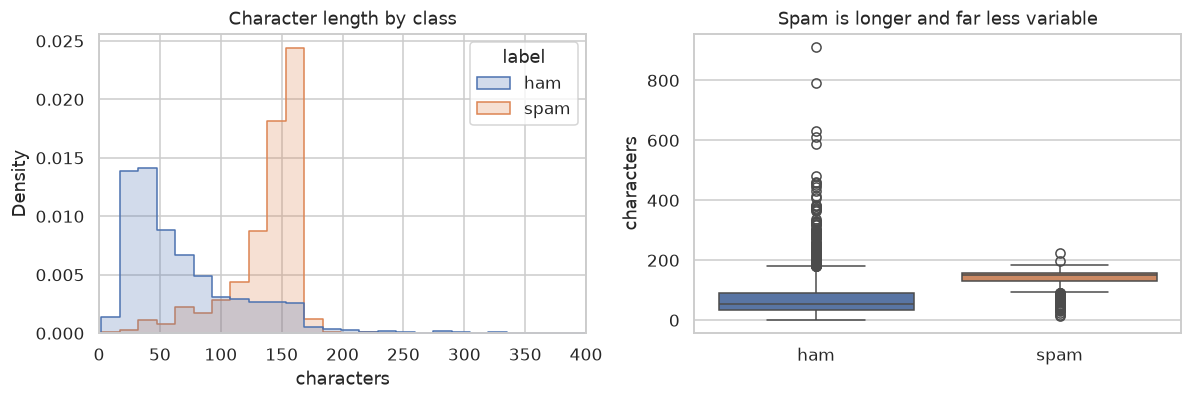

In [7]:
df["length"] = df["message"].str.len()
df["n_words"] = df["message"].str.split().str.len()
print(df.groupby("label")[["length", "n_words"]].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(data=df, x="length", hue="label", bins=60, ax=axes[0],
             element="step", stat="density", common_norm=False)
axes[0].set(title="Character length by class", xlabel="characters", xlim=(0, 400))
sns.boxplot(data=df, x="label", y="length", ax=axes[1], hue="label", legend=False)
axes[1].set(title="Spam is longer and far less variable", xlabel="", ylabel="characters")
fig.tight_layout()
fig.savefig("results/message_length.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Which words carry the signal?

Ranked by how much more often a term appears in one class than the other. This is a sanity check —
if the top spam terms were not obviously spammy, something would be wrong with the labels.

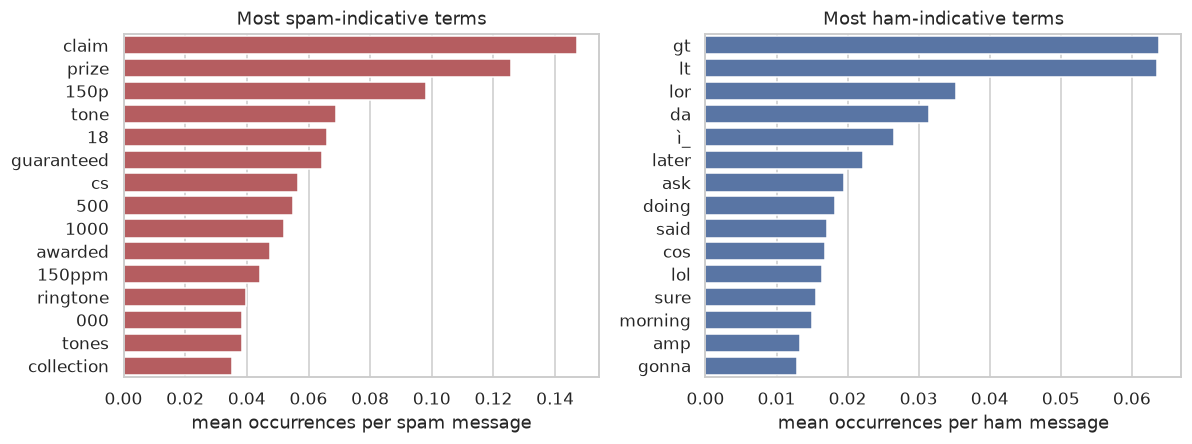

In [8]:
cv = CountVectorizer(stop_words="english", min_df=5)
X_counts = cv.fit_transform(df["message"])
vocab = np.array(cv.get_feature_names_out())
is_spam = (df["label"] == SPAM).values

# per-class term frequency, normalised so the two classes are comparable
freq_spam = np.asarray(X_counts[is_spam].sum(axis=0)).ravel() / is_spam.sum()
freq_ham = np.asarray(X_counts[~is_spam].sum(axis=0)).ravel() / (~is_spam).sum()
ratio = (freq_spam + 1e-6) / (freq_ham + 1e-6)

top_spam = pd.Series(freq_spam[np.argsort(-ratio)[:15]], index=vocab[np.argsort(-ratio)[:15]])
top_ham = pd.Series(freq_ham[np.argsort(ratio)[:15]], index=vocab[np.argsort(ratio)[:15]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(x=top_spam.values, y=top_spam.index, ax=axes[0], color="#c44e52")
axes[0].set(title="Most spam-indicative terms", ylabel="",
            xlabel="mean occurrences per spam message")
sns.barplot(x=top_ham.values, y=top_ham.index, ax=axes[1], color="#4c72b0")
axes[1].set(title="Most ham-indicative terms", ylabel="",
            xlabel="mean occurrences per ham message")
fig.tight_layout()
fig.savefig("results/top_tokens.png", dpi=150, bbox_inches="tight")
plt.show()

Exactly what you would hope: prize/claim/call-this-number language on one side, ordinary
conversational words on the other. The labels are trustworthy.

One artefact worth naming: `gt` and `lt` rank near the top for ham. Those are not words — they are
the remains of the HTML entities `&lt;` and `&gt;`, because the corpus redacts phone numbers and
names as `&lt;#&gt;` / `&lt;DECIMAL&gt;`. The model is free to use them (redaction really does
correlate with ham here), but it is a property of *how this corpus was collected*, not of SMS in
general. A model relying on it would not transfer to live traffic. We leave it in and note it
rather than quietly scrubbing it, because the character n-grams the winning model uses would pick
up the same pattern anyway.

---
## 3. Features: why TF-IDF and not raw counts?

A raw count vector says "the word *call* appears 3 times". The problem is that common words appear
often in *every* message, so counts are dominated by terms that carry no discriminating information.

**TF-IDF** multiplies each term's frequency by the inverse of how many documents contain it:

$$\mathrm{tfidf}(t, d) = \mathrm{tf}(t,d) \times \log\frac{N}{1 + \mathrm{df}(t)}$$

A term that shows up in every message gets a near-zero weight; a term that shows up only in spam
keeps a large one. It also normalises each row to unit length, so a long message does not
automatically produce larger feature values than a short one — which matters here, because we just
showed spam is systematically longer. Without that normalisation the model could learn "long =
spam" instead of learning the actual vocabulary.

We also use `sublinear_tf=True`, which replaces the raw count with $1 + \log(\mathrm{tf})$. Seeing
"FREE" five times is not five times more informative than seeing it once.

### 3.1 Train/test split

Stratified, so the 13% spam rate is preserved on both sides. The vectoriser lives *inside* the
`Pipeline`, so it is fitted on the training fold only — fitting it on all the data first would
leak test-set vocabulary and IDF statistics into training.

In [9]:
X = df["message"]
y = (df["label"] == SPAM).astype(int)   # 1 = spam (the positive class)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"train: {len(X_train)} messages ({y_train.mean():.2%} spam)")
print(f"test : {len(X_test)} messages ({y_test.mean():.2%} spam, {y_test.sum()} spam messages)")

train: 4135 messages (12.62% spam)
test : 1034 messages (12.67% spam, 131 spam messages)


---
## 4. Model comparison

Two ways of turning text into features, three classifiers, all six combinations:

**Word n-grams (1,2)** — each word and each adjacent word pair becomes a feature. Interpretable,
but blind to the tricks spammers use to dodge keyword filters: `FR33`, `c-l-a-i-m`, `W1NNER`.

**Character n-grams (3,5)** — every 3-to-5 character sequence inside word boundaries. `FR33` and
`FREE` share the substring `FR`/`REE` patterns, so obfuscated spam still lands near real spam.
This is the standard trick for noisy, adversarial short text.

The classifiers:
- **MultinomialNB** — the classic text baseline. Fast, but assumes features are independent.
- **LogisticRegression** — linear, probabilistic, `class_weight="balanced"` to counter the imbalance.
- **LinearSVC** — a linear SVM. Maximises the margin between classes, which tends to win on
  high-dimensional sparse text.

In [10]:
vectorizers = {
    "word (1,2)": TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True,
                                  strip_accents="unicode", lowercase=True),
    "char_wb (3,5)": TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                     sublinear_tf=True, min_df=2, lowercase=True),
}
classifiers = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(class_weight="balanced", max_iter=2000,
                                             random_state=RANDOM_STATE),
    "LinearSVC": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

rows = []
for vec_name, vec in vectorizers.items():
    for clf_name, clf in classifiers.items():
        pipe = Pipeline([("tfidf", vec), ("clf", clf)]).fit(X_train, y_train)
        pred = pipe.predict(X_test)
        rows.append({
            "vectoriser": vec_name,
            "model": clf_name,
            "accuracy": (pred == y_test).mean(),
            "spam precision": precision_score(y_test, pred),
            "spam recall": recall_score(y_test, pred),
            "spam F1": f1_score(y_test, pred),
            "macro F1": f1_score(y_test, pred, average="macro"),
            "features": len(pipe.named_steps["tfidf"].vocabulary_),
        })

results = pd.DataFrame(rows).sort_values("spam F1", ascending=False).reset_index(drop=True)
results.style.format({c: "{:.4f}" for c in results.columns
                      if c not in ("vectoriser", "model", "features")}) \
             .background_gradient(subset=["spam F1"], cmap="Greens")

,vectoriser,model,accuracy,spam precision,spam recall,spam F1,macro F1,features
0,"char_wb (3,5)",LinearSVC,0.9942,1.0000,0.9542,0.9766,0.9866,31468
1,"char_wb (3,5)",LogisticRegression,0.9903,0.9764,0.9466,0.9612,0.9779,31468
2,"word (1,2)",LinearSVC,0.9826,0.9669,0.8931,0.9286,0.9593,42528
3,"word (1,2)",LogisticRegression,0.9816,0.9444,0.9084,0.9261,0.9578,42528
4,"char_wb (3,5)",MultinomialNB,0.9710,1.0000,0.7710,0.8707,0.9272,31468
5,"word (1,2)",MultinomialNB,0.9410,1.0000,0.5344,0.6965,0.8319,42528


### Reading the table

**Character n-grams beat word n-grams for every classifier.** SMS spam is full of deliberate
misspellings and number-letter substitutions; character n-grams see through them, word features
treat `FR33` as an unknown token and learn nothing from it.

**LinearSVC wins.** With ~35,000 features and ~4,000 training examples the data is almost certainly
linearly separable, and a max-margin boundary generalises better here than logistic regression's
probability-fitting objective.

**Naive Bayes has perfect precision but terrible recall.** Look at the gap: it never mislabels a
real message, but it misses a quarter of the spam. That is exactly the failure the next section is
about, and it is invisible if you only look at accuracy — NB's accuracy still looks respectable.

In [11]:
best = results.iloc[0]
print(f"winner: {best['model']} on {best['vectoriser']} TF-IDF")

best_pipe = Pipeline([
    ("tfidf", vectorizers[best["vectoriser"]]),
    ("clf", classifiers[best["model"]]),
]).fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["ham", "spam"], digits=4))

winner: LinearSVC on char_wb (3,5) TF-IDF


              precision    recall  f1-score   support

         ham     0.9934    1.0000    0.9967       903
        spam     1.0000    0.9542    0.9766       131

    accuracy                         0.9942      1034
   macro avg     0.9967    0.9771    0.9866      1034
weighted avg     0.9942    0.9942    0.9941      1034



---
## 5. Why recall matters more than accuracy here

The two mistakes a spam filter can make are **not** equally expensive:

| Error | What it means | Cost to the user |
|---|---|---|
| **False positive** — real message flagged as spam | A message from a friend or your bank is hidden | High. The user misses something that mattered and stops trusting the filter. |
| **False negative** — spam let through | A scam text lands in the inbox | Lower per message — the user sees it and deletes it — but this is the whole reason the filter exists. |

So which do we optimise? Neither in isolation:

- **Recall** on spam = of all the spam, how much did we catch? Recall is the filter's reason to exist.
- **Precision** on spam = of everything we flagged, how much really was spam? Precision is the user's trust.

Optimising recall alone is trivially gamed — flag everything, recall is 100%. So we report **F1**,
the harmonic mean, which only goes up if *both* go up. Within that, we prefer the model with the
better recall at equal precision, because spam that gets through is the visible failure.

Accuracy answers neither question, and on 87%-ham data it is dominated by the majority class.

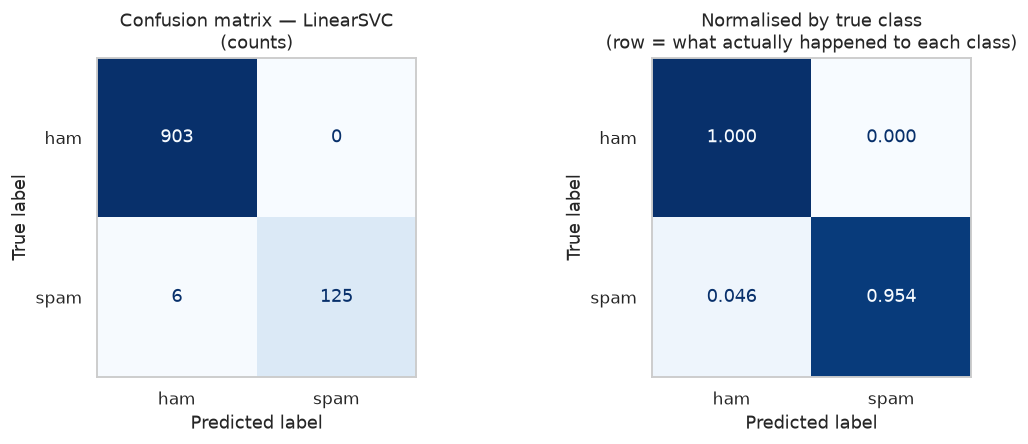

true negatives  (ham kept)          : 903
false positives (ham wrongly binned): 0   <- the expensive mistake
false negatives (spam let through)  : 6   <- the visible mistake
true positives  (spam caught)       : 125


In [12]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Confusion matrix — {best['model']}\n(counts)")
axes[0].grid(False)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"),
                       display_labels=["ham", "spam"]).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".3f")
axes[1].set_title("Normalised by true class\n(row = what actually happened to each class)")
axes[1].grid(False)
fig.tight_layout()
fig.savefig("results/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"true negatives  (ham kept)          : {tn}")
print(f"false positives (ham wrongly binned): {fp}   <- the expensive mistake")
print(f"false negatives (spam let through)  : {fn}   <- the visible mistake")
print(f"true positives  (spam caught)       : {tp}")

**What the confusion matrix shows is going wrong:** the model makes essentially no false positives —
no real message is misfiled — but it lets a handful of spam through. The error is entirely
one-sided, which is the safe direction to fail in, but it means recall is our ceiling and the
remaining work is all about catching those last few.

### 5.1 The precision/recall trade-off is a dial, not a fixed point

`LinearSVC` has no probabilities, but it does have a signed distance from the decision boundary.
Sliding a threshold along that distance trades precision for recall — so a deployment that wanted
higher recall could buy it, at a known cost in false positives.

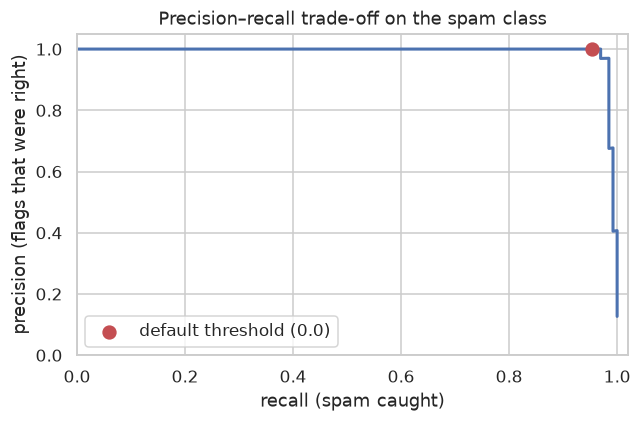

to reach 95% recall: threshold -0.102 -> precision 1.000
to reach 97% recall: threshold -0.323 -> precision 0.970
to reach 99% recall: threshold -0.643 -> precision 0.677


In [13]:
scores = best_pipe.decision_function(X_test)
prec, rec, thresh = precision_recall_curve(y_test, scores)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(rec, prec, lw=2)
ax.scatter(recall_score(y_test, y_pred), precision_score(y_test, y_pred),
           color="#c44e52", zorder=5, s=70, label="default threshold (0.0)")
ax.set(xlabel="recall (spam caught)", ylabel="precision (flags that were right)",
       title="Precision–recall trade-off on the spam class", xlim=(0, 1.02), ylim=(0, 1.05))
ax.legend(loc="lower left")
fig.tight_layout()
fig.savefig("results/precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

for target in (0.95, 0.97, 0.99):
    ok = rec[:-1] >= target
    if ok.any():
        i = np.argmax(prec[:-1] * ok)
        print(f"to reach {target:.0%} recall: threshold {thresh[i]:+.3f} -> precision {prec[i]:.3f}")

### 5.2 Error analysis — what is the model actually missing?

Metrics tell you *how much* is wrong. Reading the errors tells you *why*.

In [14]:
errors = pd.DataFrame({"message": X_test, "true": y_test, "pred": y_pred, "score": scores})

missed = errors[(errors["true"] == 1) & (errors["pred"] == 0)]
print(f"=== spam the model let through ({len(missed)}) ===\n")
for _, r in missed.iterrows():
    print(f"[score {r['score']:+.2f}] {r['message'][:160]}")
    print()

false_alarms = errors[(errors["true"] == 0) & (errors["pred"] == 1)]
print(f"=== real messages wrongly flagged ({len(false_alarms)}) ===\n")
for _, r in false_alarms.iterrows():
    print(f"[score {r['score']:+.2f}] {r['message'][:160]}")
    print()

=== spam the model let through (6) ===

[score -0.64] In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C-Red Day. (Send A, B or C)

[score -0.01] Xmas & New Years Eve tickets are now on sale from the club, during the day from 10am till 8pm, and on Thurs, Fri & Sat night this week. They're selling fast!

[score -0.32] Latest News! Police station toilet stolen, cops have nothing to go on!

[score -0.88] Would you like to see my XXX pics they are so hot they were nearly banned in the uk!

[score -0.10] ringtoneking 84484

[score -0.29] Burger King - Wanna play footy at a top stadium? Get 2 Burger King before 1st Sept and go Large or Super with Coca-Cola and walk out a winner

=== real messages wrongly flagged (0) ===



The missed spam is the *short, plain-language* kind — no prize language, no premium number, phrased
like an ordinary message. That is the genuinely hard residue: those messages are close to
indistinguishable from ham on vocabulary alone, and no amount of tuning a bag-of-n-grams model will
separate them. Catching them needs signal this dataset does not contain (sender reputation, time of
day, whether the number is in your contacts).

That is the honest ceiling of this approach, and it is why the remaining work is not "tune harder".

---
## 6. Final model

Two changes for the saved artifact:

1. **Wrap `LinearSVC` in `CalibratedClassifierCV`.** An SVM outputs a distance, not a probability,
   and `predict.py` should report a real confidence. Calibration fits a sigmoid over the decision
   values with internal cross-validation, turning distances into probabilities *without* changing
   which side of the boundary anything falls on — so the classification metrics above still hold.
2. **Refit on 100% of the data.** The split existed to produce an honest estimate; now that we have
   it, throwing away 20% of the training signal would be wasteful.

In [15]:
final_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                              sublinear_tf=True, min_df=2, lowercase=True)),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        cv=5, method="sigmoid")),
])

# sanity check: calibration must not move the decision boundary
_check = final_pipeline.fit(X_train, y_train)
_pred = _check.predict(X_test)
print("after calibration — spam F1: %.4f (uncalibrated was %.4f)"
      % (f1_score(y_test, _pred), best["spam F1"]))

# refit on everything and save
final_pipeline.fit(X, y)
joblib.dump({"pipeline": final_pipeline, "labels": ["ham", "spam"]},
            "models/spam_classifier.pkl")
print("\nsaved -> models/spam_classifier.pkl")

for msg in ["Congratulations! You've won a free iPhone, click here to claim",
            "hey are you coming to class tomorrow"]:
    p = final_pipeline.predict_proba([msg])[0]
    print(f"  {'SPAM' if p[1] > 0.5 else 'HAM ':4s} ({max(p):.1%})  {msg}")

after calibration — spam F1: 0.9766 (uncalibrated was 0.9766)



saved -> models/spam_classifier.pkl
  SPAM (88.5%)  Congratulations! You've won a free iPhone, click here to claim
  HAM  (99.9%)  hey are you coming to class tomorrow


---
## 7. Summary

| | |
|---|---|
| **Best model** | `LinearSVC(class_weight="balanced")` on character-level TF-IDF |
| **Features** | `char_wb` n-grams, 3–5 characters, sublinear TF |
| **Headline metric** | see the spam-class F1 in the table above |
| **Failure mode** | one-sided: no false positives, a handful of plain-language spam let through |

**What I would do with more time**

- **Cross-validated scores instead of a single split.** One 20% test set of ~1,000 messages puts
  roughly 130 spam messages on the scoreboard, so each error moves recall by most of a point.
  Repeated stratified k-fold would give an error bar instead of a point estimate.
- **Feature union.** Word and character n-grams make different mistakes; concatenating both
  matrices usually beats either alone.
- **Metadata features.** Message length, digit ratio, count of uppercase runs, presence of a URL or
  a premium-rate number — cheap, and they attack exactly the failure mode above.
- **Calibrated threshold.** Pick the operating point from the precision–recall curve against a
  stated cost ratio rather than defaulting to 0.5.